📂 Loading and Merging all 4 NASA Datasets...
🔄 Normalizing sensors across 6 operating regimes...
⚙️ Generating Rolling Mean & Std features...


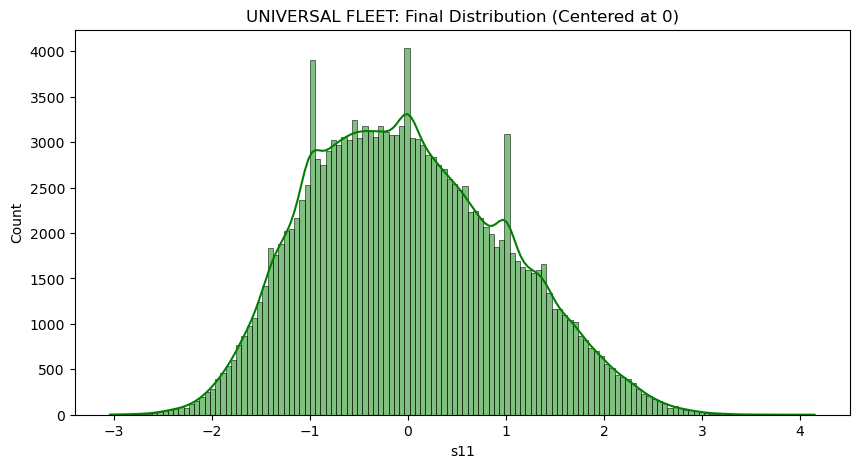

✅ SUCCESS: Phase-1 Complete!
Final Fleet Size: 709 Engines
Total Rows: 160359 | Total Features: 66


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Column Names
index_cols = ['id', 'cycle']
setting_cols = ['set1', 'set2', 'set3']
sensor_cols = [f's{i}' for i in range(1, 22)]
cols = index_cols + setting_cols + sensor_cols

# 2. Unified Loader (Fixes ID Collision & RUL per file)
def load_and_prep(file_path, file_id):
    # Use r'' to avoid SyntaxWarnings on Fedora
    df = pd.read_csv(file_path, sep=r'\s+', header=None, names=cols)
    
    # Make IDs unique across the 4 datasets (1001, 2001, 3001, 4001)
    df['id'] = df['id'] + (file_id * 1000)
    
    # Calculate RUL
    max_cycle = df.groupby('id')['cycle'].max().reset_index()
    max_cycle.columns = ['id', 'max']
    df = df.merge(max_cycle, on=['id'], how='left')
    df['RUL'] = (df['max'] - df['cycle']).clip(upper=125)
    df.drop('max', axis=1, inplace=True)
    return df

print("📂 Loading and Merging all 4 NASA Datasets...")
data_path = '../DATASETS/'
train_df = pd.concat([
    load_and_prep(data_path + 'train_FD001.txt', 1),
    load_and_prep(data_path + 'train_FD002.txt', 2),
    load_and_prep(file_path=data_path + 'train_FD003.txt', file_id=3),
    load_and_prep(file_path=data_path + 'train_FD004.txt', file_id=4)
], ignore_index=True)

# 3. The "Excellence" Scaling (Centers different flight altitudes at 0)
def scale_by_condition(group):
    group_scaler = StandardScaler()
    group[sensor_cols] = group_scaler.fit_transform(group[sensor_cols])
    return group

print("🔄 Normalizing sensors across 6 operating regimes...")
# include_groups=False silences the Futureware Warning
train_df = train_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition, include_groups=False)

# 4. Feature Engineering (Adding Trends/Memory)
window_size = 5
print("⚙️ Generating Rolling Mean & Std features...")
train_df[ [f'{s}_mean' for s in sensor_cols] ] = train_df.groupby('id')[sensor_cols].transform(lambda x: x.rolling(window=window_size).mean())
train_df[ [f'{s}_std' for s in sensor_cols] ] = train_df.groupby('id')[sensor_cols].transform(lambda x: x.rolling(window=window_size).std())

# Remove NaNs created by the rolling window
train_df.bfill(inplace=True)

# 5. Final Verification Plot
plt.figure(figsize=(10, 5))
sns.histplot(train_df['s11'], kde=True, color='green')
plt.title('UNIVERSAL FLEET: Final Distribution (Centered at 0)')
plt.show()

# 6. Save the Universal Dataset
train_df.to_csv('../DATASETS/universal_train.csv', index=False)

print(f"✅ SUCCESS: Phase-1 Complete!")
print(f"Final Fleet Size: {train_df['id'].nunique()} Engines")
print(f"Total Rows: {len(train_df)} | Total Features: {len(train_df.columns)}")

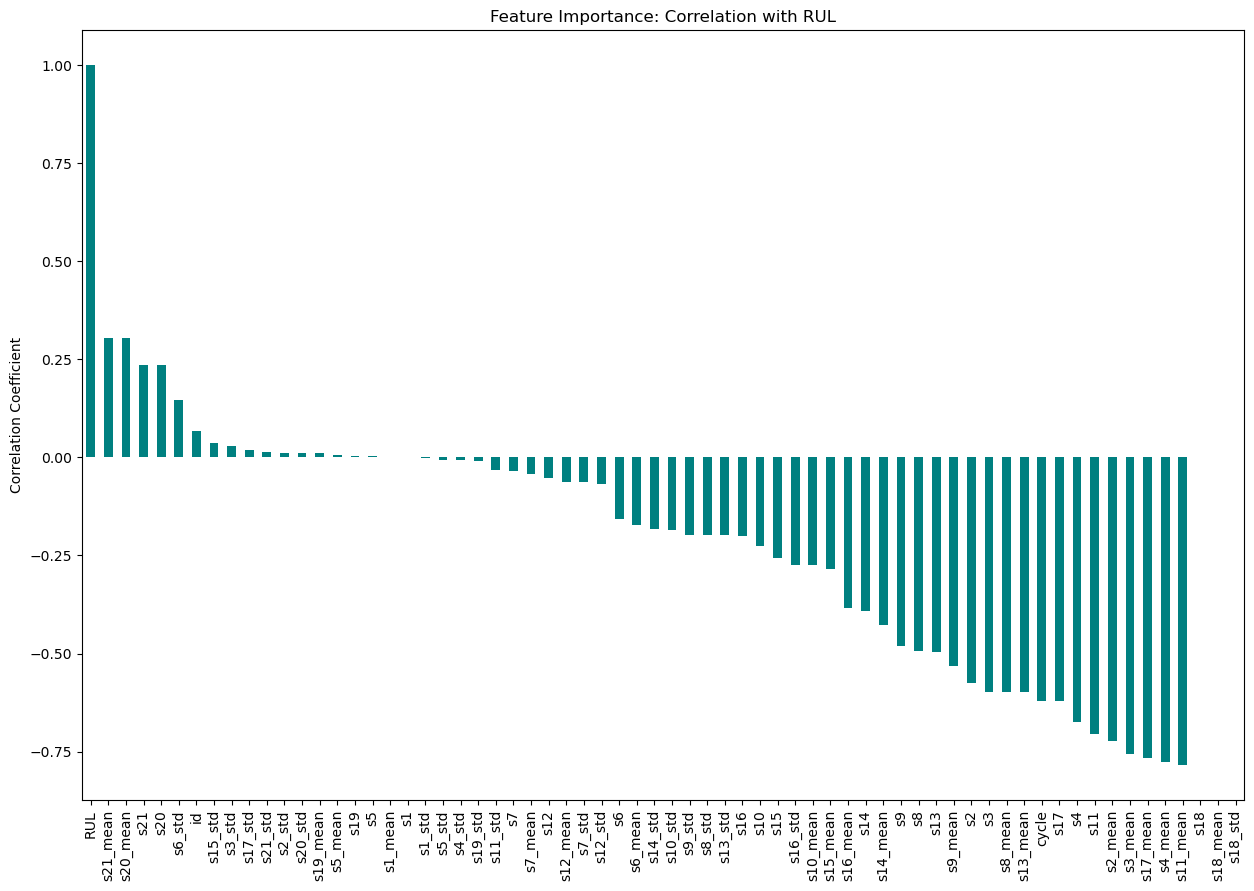

In [2]:
# Final Step: Correlation Check
plt.figure(figsize=(15, 10))
# Check correlation of sensors + rolling features against RUL
corr = train_df.corr()['RUL'].sort_values(ascending=False)
corr.plot(kind='bar', color='teal')
plt.title("Feature Importance: Correlation with RUL")
plt.ylabel("Correlation Coefficient")
plt.show()